In [1]:
import readligo
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [46]:
dirname = "/Users/saifa/Library/CloudStorage/OneDrive-weizmann.ac.il/O3a_marvin/"
hdf5_files = list(Path(dirname).glob("*.hdf5"))
hdf5_files_sorted = sorted(
    hdf5_files,
    key=lambda p: int(p.stem.split('-')[-2])
)


filename = hdf5_files_sorted[0].name
strain, gpsStart, ts, qmask, shortnameList, injmask, injnameList = readligo.read_hdf5(dirname + filename)
strain, time, channel_dict = readligo.loaddata(dirname + filename)
gpsStart, channel_dict

(1238163456.0,
 {'DATA': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'CBC_CAT1': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'CBC_CAT2': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'CBC_CAT3': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'BURST_CAT1': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'BURST_CAT2': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'BURST_CAT3': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'NO_CBC_HW_INJ': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'NO_BURST_HW_INJ': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'NO_DETCHAR_HW_INJ': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'NO_CW_HW_INJ': array([0, 0, 0, ..., 0, 0, 0], shape=(4096,), dtype=uint32),
  'NO_STOCH_HW_INJ': array([0, 0, 0, ..., 1, 1, 1], shape=(4096,), dtype=uint32),
  'DEFAULT': array([0, 0, 0, ..., 1, 1, 1], shape=(

In [47]:
dq_mask = (channel_dict["DATA"] == 1) & (channel_dict['CBC_CAT1'] == 1)
fs = 4096
dq_mask_fs = np.repeat(dq_mask, fs)
clean_strain = np.copy(strain)
clean_strain[~dq_mask_fs] = 0.0

print(f"Original strain shape: {strain.shape}")
print(f"Stretched mask shape:  {dq_mask_fs.shape}")
print(f"Data zeroed out:       {np.sum(~dq_mask_fs)} samples")
print(f"duty factor:     {1-(np.sum(~dq_mask_fs)/len(dq_mask_fs)):.3f}")

Original strain shape: (16777216,)
Stretched mask shape:  (16777216,)
Data zeroed out:       10493952 samples
duty factor:     0.375


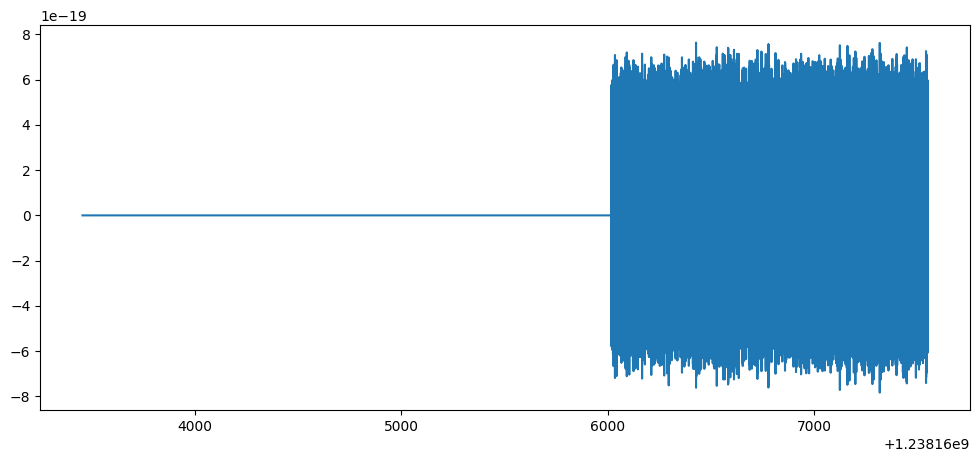

In [48]:
file_gps_time = np.arange(gpsStart, gpsStart + 4096, ts)

plt.figure(figsize=(12, 5))
plt.plot(file_gps_time, clean_strain)

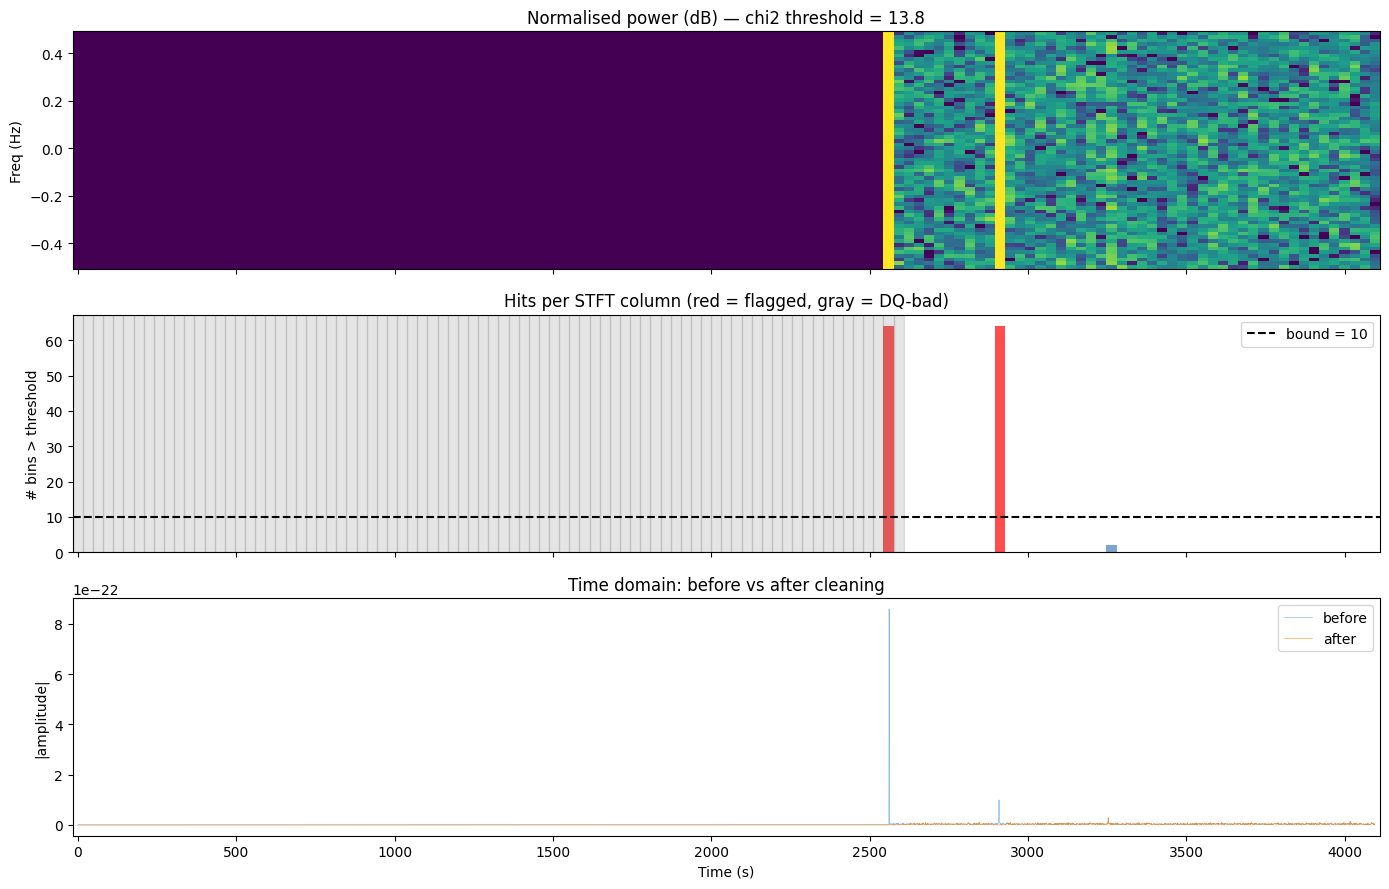

In [49]:
from readligo import process_band

gps_times, cleaned, sample_mask, fs_new = process_band(strain, channel_dict, gpsStart, (100, 101), plot=True)

In [50]:
from readligo import apply_dq_mask, heterodyne_downsample, clean_narrowband

nperseg = 64
fap = 0.001
bound = 10
clean_strain, dq_mask_1hz = apply_dq_mask(strain, channel_dict, fs)
narrowband, fs_new = heterodyne_downsample(clean_strain, fs, f_band=(100, 101))
cleaned, sample_mask, diag = clean_narrowband(
        narrowband,
        dq_mask_1hz,
        fs_new,
        nperseg=nperseg,
        fap=fap,
        bound=bound,
    )

In [51]:
bad_col_mask = diag["bad_col_mask"]
good_cols = diag["good_cols"]
col_hits = diag["col_hits"]
threshold = diag["threshold"]
time_bins = diag["time_bins"]

# All columns should be DQ-good (100% duty)
print(f"DQ-good columns: {np.sum(good_cols)} / {len(good_cols)}")

# How many columns flagged as artifacts?
artifact_cols = (col_hits > bound) & good_cols
n_bad = np.sum(artifact_cols)
print(f"Artifact columns: {n_bad}")

# Which columns, and how many hits each?
bad_indices = np.where(artifact_cols)[0]
for idx in bad_indices:
    center = int(round(time_bins[idx] * fs_new))
    lo = max(0, center - nperseg // 2)
    hi = min(len(cleaned), center + nperseg // 2)
    print(f"  col {idx}: center={center}s, samples [{lo}, {hi}), "
        f"col_hits={col_hits[idx]}, width={hi-lo} samples")

# How sample_mask count adds up (bad columns can overlap by hop=32 samples)
print(f"\nExpected if no overlap: {n_bad} cols × {nperseg} samples = {n_bad * nperseg}")
print(f"Actual sample_mask False: {np.sum(~sample_mask)}")
print(f"Difference due to overlapping windows or edge clamping: "
    f"{n_bad * nperseg - np.sum(~sample_mask)}")

# How cleaned==0 count relates
print(f"\ncleaned == 0: {np.sum(cleaned == 0)}")
print(f"sample_mask False: {np.sum(~sample_mask)}")
print(f"Difference (boundary bleed from overlap-add): "
    f"{np.sum(~sample_mask) - np.sum(cleaned == 0)}")

DQ-good columns: 47 / 129
Artifact columns: 1
  col 91: center=2912s, samples [2880, 2944), col_hits=64, width=64 samples

Expected if no overlap: 1 cols × 64 samples = 64
Actual sample_mask False: 2688
Difference due to overlapping windows or edge clamping: -2624

cleaned == 0: 2594
sample_mask False: 2688
Difference (boundary bleed from overlap-add): 94


## Check 1: DQ-bad regions → sample_mask = False

In [52]:
# Build a per-sample DQ mask at the downsampled rate.
# Each downsampled sample i corresponds to time i/fs_new seconds,
# i.e. DQ second index floor(i/fs_new).  fs_new == 1 Hz for a 1-Hz band,
# so it's a 1:1 mapping in that case.
n_ds = len(cleaned)
dq_sample = np.ones(n_ds, dtype=bool)
for i in range(n_ds):
    t_sec = i / fs_new          # time in seconds from file start
    dq_idx = int(np.floor(t_sec))
    if dq_idx < len(dq_mask_1hz):
        dq_sample[i] = dq_mask_1hz[dq_idx]
    else:
        dq_sample[i] = False    # beyond file → treat as bad

# For every sample where DQ is bad, sample_mask must also be False
dq_bad_samples = ~dq_sample
leak_count = np.sum(dq_bad_samples & sample_mask)

print(f"Downsampled samples:        {n_ds}")
print(f"DQ-bad samples (1 Hz map):  {np.sum(dq_bad_samples)}")
print(f"sample_mask=False:          {np.sum(~sample_mask)}")
print(f"DQ-bad BUT sample_mask=True (leaks): {leak_count}")
if leak_count == 0:
    print("✓ All DQ-bad samples are correctly masked.")
else:
    # Show which samples leak
    leak_idx = np.where(dq_bad_samples & sample_mask)[0]
    print(f"✗ Leak at sample indices: {leak_idx[:20]}{'...' if len(leak_idx)>20 else ''}")

Downsampled samples:        4096
DQ-bad samples (1 Hz map):  2562
sample_mask=False:          2688
DQ-bad BUT sample_mask=True (leaks): 0
✓ All DQ-bad samples are correctly masked.


## Check 2: Data loss breakdown — DQ vs transient cleaning

In [53]:
from readligo import data_loss_breakdown

breakdown = data_loss_breakdown(sample_mask, dq_mask_1hz, diag, bound=bound)

print(f"=== Per-sample breakdown (fs_new = {fs_new} Hz) ===")
print(f"Total samples:               {breakdown['n_samples']}")
print(f"Lost to DQ (bad seconds):    {breakdown['n_dq_loss']:>6d}  ({100*breakdown['n_dq_loss']/breakdown['n_samples']:.1f}%)")
print(f"Lost to STFT boundary:       {breakdown['n_boundary_loss']:>6d}  ({100*breakdown['n_boundary_loss']/breakdown['n_samples']:.1f}%)")
print(f"Lost to transient cleaning:  {breakdown['n_artifact_loss']:>6d}  ({100*breakdown['n_artifact_loss']/breakdown['n_samples']:.1f}%)")
n_lost = breakdown['n_dq_loss'] + breakdown['n_boundary_loss'] + breakdown['n_artifact_loss']
print(f"Total lost:                  {n_lost:>6d}  ({100*n_lost/breakdown['n_samples']:.1f}%)")
print(f"Usable data:                 {breakdown['n_usable']:>6d}  ({100*breakdown['n_usable']/breakdown['n_samples']:.1f}%)")
print(f"Duty factor:                 {breakdown['duty_factor']:.3f}")

=== Per-sample breakdown (fs_new = 1.0 Hz) ===
Total samples:               4096
Lost to DQ (bad seconds):      2562  (62.5%)
Lost to STFT boundary:           62  (1.5%)
Lost to transient cleaning:      64  (1.6%)
Total lost:                    2688  (65.6%)
Usable data:                   1408  (34.4%)
Duty factor:                 0.344
